In [271]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# For machine learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn import tree

In [4]:
# Load the dataset
dataset = pd.read_csv("50_Startups.csv")

In [257]:
# Quick view of the data
print(dataset.head())
print(dataset.describe())
print(dataset.info())

   R&D Spend  Administration  Marketing Spend     Profit  State_California  \
0  165349.20       136897.80        471784.10  192261.83             False   
1  162597.70       151377.59        443898.53  191792.06              True   
2  153441.51       101145.55        407934.54  191050.39             False   
3  144372.41       118671.85        383199.62  182901.99             False   
4  142107.34        91391.77        366168.42  166187.94             False   

   State_Florida  State_New York  
0          False            True  
1          False           False  
2           True           False  
3          False            True  
4           True           False  
           R&D Spend  Administration  Marketing Spend         Profit
count      50.000000       50.000000        50.000000      50.000000
mean    73721.615600   121344.639600    211025.097800  112012.639200
std     45902.256482    28017.802755    122290.310726   40306.180338
min         0.000000    51283.140000         

In [12]:
# Handle categorical variable (State)
dataset = pd.get_dummies(dataset, drop_first = 1)

In [16]:
# List of dataset columns
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_California', 'State_Florida', 'State_New York'],
      dtype='object')

In [25]:
# Define features and target variable
x = dataset.drop("Profit", axis = 1)

In [29]:
y = dataset[["Profit"]]

In [56]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [243]:
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html
model = DecisionTreeRegressor(
    criterion='absolute_error',
    splitter='best',
    max_features = 'sqrt',
    random_state=42
)
model.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_features='sqrt',
                      random_state=42)

In [245]:
model.get_params

<bound method BaseEstimator.get_params of DecisionTreeRegressor(criterion='absolute_error', max_features='sqrt',
                      random_state=42)>

In [247]:
y_pred = model.predict(X_test)

In [249]:
y_pred

array([126992.93,  89949.14, 110352.25,  69758.98, 129917.04,  69758.98,
       103282.38, 126992.93, 126992.93, 103282.38])

In [251]:
r2_result = r2_score(y_test, y_pred)

In [253]:
r2_result

0.6182161344208568

In [269]:
mse = mean_squared_error(y_test, y_pred)
mse

309165548.21123993

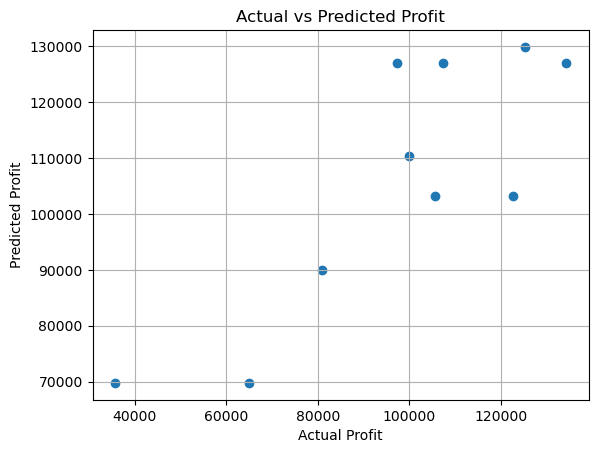

In [255]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.grid(1)
plt.show()

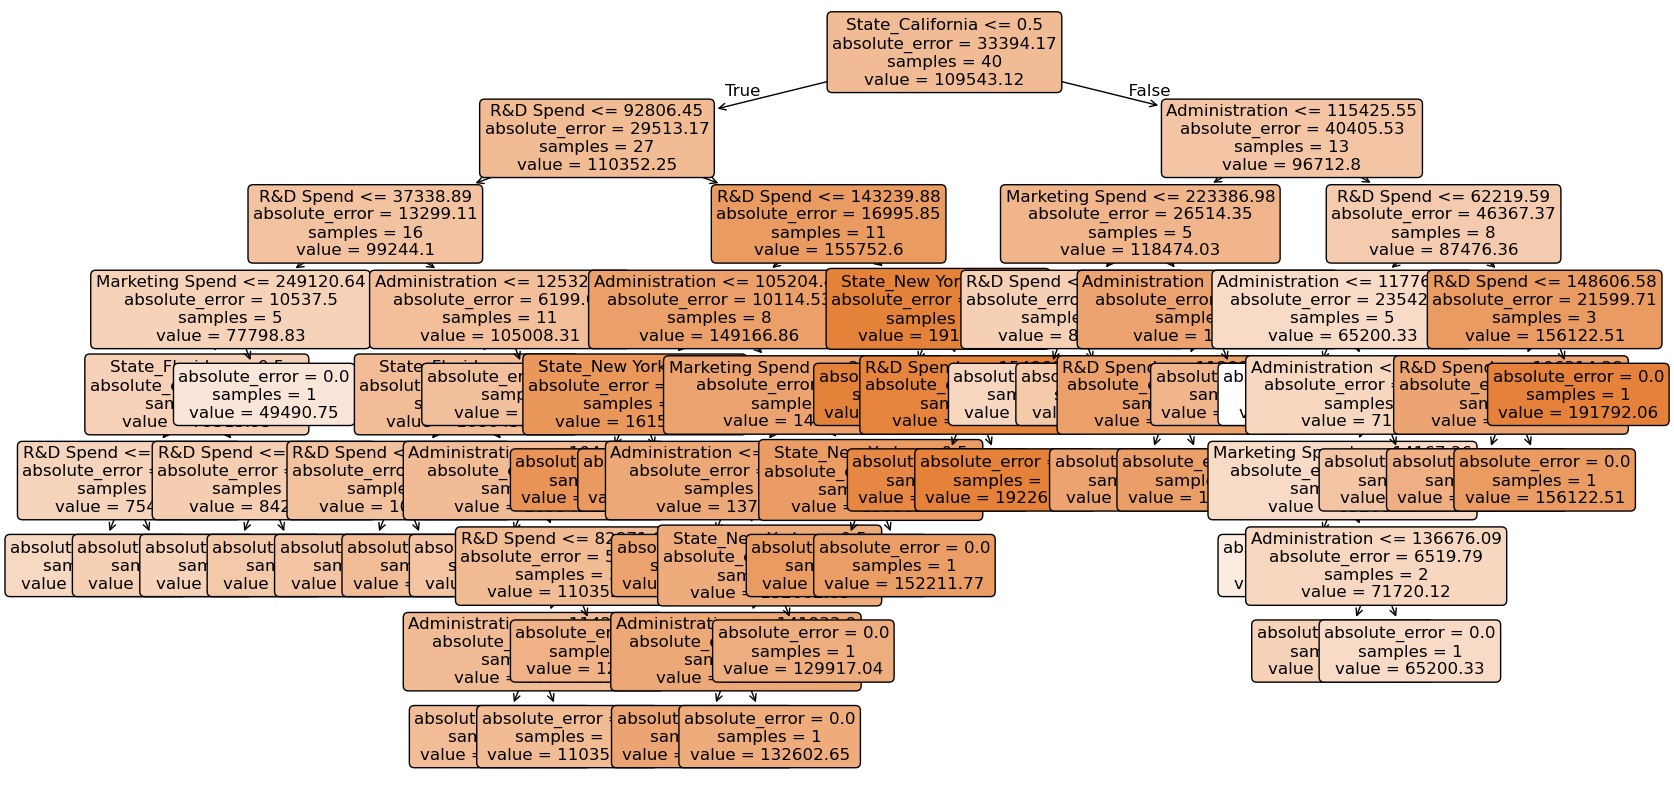

In [287]:
plt.figure(figsize=(20,10))
tree.plot_tree(
    model, 
    feature_names=x.columns,
    filled=True,
    rounded=True,
    fontsize=12,
    precision=2
)
plt.show()